<a href="https://colab.research.google.com/github/Mayfm/wildlife-bacterial-dynamics/blob/main/Project_code_wildlife_and_bacterial_dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Distribución temporal y predicción del grupo de hospedero de aislamientos bacterianos asociados a animales silvestres





## Introducción

---



Los animales silvestres pueden albergar una gran diversidad de microorganismos asociados con diferentes tejidos, ambientes y condiciones ecológicas. Las bases de datos genómicas permiten reunir información de numerosos aislamientos bacterianos junto con datos sobre el hospedero, el lugar y el momento de aislamiento y características del genoma.

En este proyecto se analizaron aislamientos bacterianos asociados a diferentes animales silvestres para explorar su distribución a través del tiempo, las diferencias entre grupos de hospederos y su distribución geográfica. Además, se evaluó si algunas características genómicas permiten predecir el grupo de hospedero asociado a un aislamiento bacteriano.

## Preguntas de investigación




¿Cómo ha cambiado a través del tiempo la distribución de los grupos bacterianos asociados a animales silvestres?

Las características genómicas permiten predecir el grupo de hospedero asociado con un aislamiento bacteriano?

##Objetivos

---



Analizar la distribución temporal, taxonómica y geográfica de los grupos bacterianos asociados a animales silvestres y evaluar si las características genómicas permiten predecir el grupo de hospedero a partir de datos disponibles en BV-BRC.

###Objetivos específicos

* Caracterizar los registros de genomas bacterianos asociados a diferentes animales silvestres.
* Describir la distribución de los aislamientos bacterianos a través del tiempo.
* Comparar la composición taxonómica bacteriana entre diferentes grupos de hospederos.
* Explorar la distribución geográfica de los registros bacterianos.
* Analizar algunas características genómicas, como tamaño del genoma y contenido de GC.
* Evaluar si las características genómicas permiten predecir el grupo de hospedero mediante un modelo de clasificación.
* Identificar patrones temporales, biológicos y geográficos dentro del conjunto de datos.





## Fuente de datos

---



Los datos fueron obtenidos de BV-BRC (Bacterial and Viral Bioinformatics Resource Center), utilizando la sección Genomes y realizando búsquedas por hospedero (`Host Common Name`).

Se seleccionaron diferentes hospederos pertenecientes a fauna silvestre y sus registros genómicos fueron descargados individualmente en formato CSV. Posteriormente, los archivos fueron integrados en un único conjunto de datos.

### Carga de la base de datos

Los archivos CSV descargados de BV-BRC contenían información sobre los genomas bacterianos asociados a los diferentes hospederos seleccionados. Debido a que presentaban una estructura de columnas compatible, los archivos se integraron verticalmente mediante ` pandas.concat()`, conservando los registros de cada archivo.

In [8]:
# Instalar gdown
!pip -q install -U gdown

import gdown
import os
import glob

# Enlace público de la carpeta de Google Drive
FOLDER_URL = "https://drive.google.com/drive/folders/1Fzk2gi9Lhj2UeywlomjmRfJrRvfSYrT5?usp=sharing"

# Carpeta temporal de trabajo en Colab
DATA_DIR = "/content/data"

# Crear carpeta
os.makedirs(DATA_DIR, exist_ok=True)

# Descargar todos los archivos de la carpeta
gdown.download_folder(
    url=FOLDER_URL,
    output=DATA_DIR,
    quiet=False
)

print("\nDatos descargados.")

Retrieving folder contents


Processing file 1NTr4WuWLX-NHPZsCQ3rHicc4lHy11Wyy BVBRC_genome_atlantic_salmon.csv
Processing file 19YrmUTlxWVs4GriNrihBDjn99ZAVt_WE BVBRC_genome_bat.csv
Processing file 1DyGnlQiTqzGVld6j-CTtRPQ4fMOK5P6d BVBRC_genome_bottlenose.csv
Processing file 1OsInUWuC1i0ybeu9CAFcZNf8tByLKu6m BVBRC_genome_chimpanzee.csv
Processing file 14_qGbGdi7oasyhKK8_CYDMdwKnHMFE9O BVBRC_genome_crow.csv
Processing file 1UQXme_8AZJtg8ZBmxNu522yzpxEzVo1q BVBRC_genome_deer.csv
Processing file 14UK691UGvq6B2Qp48UOOFLJx7qBMMNWw BVBRC_genome_dolphin.csv
Processing file 1Pxc7HMBfb8s_ftwSI9qu44MIqpy6twx8 BVBRC_genome_gorilla.csv
Processing file 1hHKPau5IMLm-LFnSBF6oM4x0g9fmkzB- BVBRC_genome_gull.csv
Processing file 1Om1oq9SPSKfM6eD1O1eePedjkZDTO6IB BVBRC_genome_koala.csv
Processing file 1BZAKTKLudNV-w82uIOBWFDXPz32YaR7p BVBRC_genome_macaque.csv
Processing file 166iLyUHQq-3kxKeptcBsYJGZIIcsj1M9 BVBRC_genome_mallard.csv
Processing file 1LNeYK8vdbGHvXngGR5hKCLXB35jqK84R BVBRC_genome_marmot.csv
Processing file 12J7UHwXa1r

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1NTr4WuWLX-NHPZsCQ3rHicc4lHy11Wyy
To: /content/data/BVBRC_genome_atlantic_salmon.csv
100%|██████████| 554k/554k [00:00<00:00, 27.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=19YrmUTlxWVs4GriNrihBDjn99ZAVt_WE
To: /content/data/BVBRC_genome_bat.csv
100%|██████████| 615k/615k [00:00<00:00, 14.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DyGnlQiTqzGVld6j-CTtRPQ4fMOK5P6d
To: /content/data/BVBRC_genome_bottlenose.csv
100%|██████████| 269k/269k [00:00<00:00, 7.41MB/s]
Downloading...
From: https://drive.google.com/uc?id=1OsInUWuC1i0ybeu9CAFcZNf8tByLKu6m
To: /content/data/BVBRC_genome_chimpanzee.csv
100%|██████████| 229k/229k [00:00<00:00, 9.01MB/s]
Downloading...
From: https://drive.google.com/uc?id=14_qGbGdi7oasyhKK8_CYDMdwKnHMFE9O
To: /content/data/BVBRC_genome_crow.csv
100%|██████████| 196k/196k [00:00<00:00


Datos descargados.



Download completed


La base de datos estuvo conformada por 13,794 registros y 90 variables.


In [11]:
# Buscar todos los archivos de BV-BRC
archivos = glob.glob("/content/data/BVBRC_genome_*.csv")

# Leer cada archivo
tablas = [pd.read_csv(archivo) for archivo in archivos]

# Unir todas las tablas
wildlife = pd.concat(tablas, ignore_index=True)

print("Filas:", wildlife.shape[0])
print("Columnas:", wildlife.shape[1])

Filas: 13794
Columnas: 90


## Exploración de los datos





Se mostraron los primeros registros del conjunto de datos para verificar que la información se hubiera cargado correctamente y observar su estructura general.

In [6]:
wildlife.head()

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,Host Age,Host Health,Host Group,Lab Host,Passage,Other Clinical,Additional Metadata,Comments,Date Inserted,Date Modified
0,1017266.300,Lactococcus garvieae UNIUD074,NaN,1017266,131567;2;1783272;1239;91061;186826;1300;1357;1...,cellular organisms;Bacteria;Bacillati;Bacillot...,Bacteria,Bacillati,Bacillota,Bacilli,...,NaN,NaN,Fish,NaN,NaN,NaN,NaN,The strain Lactococcus garvieae UNIUD074 is be...,2014-12-08T22:11:55.166Z,2015-03-16T03:17:09.594Z
1,1037377.300,Chryseobacterium viscerum strain 687B-08,NaN,1037377,131567;2;3379134;1783270;68336;976;117743;2006...,cellular organisms;Bacteria;Pseudomonadati;FCB...,Bacteria,Pseudomonadati,Bacteroidota,Flavobacteriia,...,NaN,NaN,Fish,NaN,NaN,NaN,sample_type:cell culture,Chryseobacterium viscerum 687B-08 Genome seque...,2018-05-25T20:10:36.051Z,2018-05-25T20:10:36.051Z
2,105751.600,Aeromonas bestiarum strain GA97-22,NaN,105751,131567;2;3379134;1224;1236;135624;84642;642;10...,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,Fish,NaN,NaN,NaN,sample_type:whole organism,Aeromonas bestiarum belongs a group of mesophi...,2018-05-25T20:59:32.581Z,2018-05-25T20:59:32.581Z
3,107401.175,Tenacibaculum maritimum TCFB 0814,NaN,107401,131567;2;3379134;1783270;68336;976;117743;2006...,cellular organisms;Bacteria;Pseudomonadati;FCB...,Bacteria,Pseudomonadati,Bacteroidota,Flavobacteriia,...,NaN,NaN,Fish,NaN,NaN,NaN,sample_type:cell culture;biomaterial_provider:...,NaN,2025-01-31T03:50:21.277Z,2025-01-31T03:50:21.277Z
4,107401.177,Tenacibaculum maritimum TCFB 0856,NaN,107401,131567;2;3379134;1783270;68336;976;117743;2006...,cellular organisms;Bacteria;Pseudomonadati;FCB...,Bacteria,Pseudomonadati,Bacteroidota,Flavobacteriia,...,NaN,NaN,Fish,NaN,NaN,NaN,sample_type:cell culture;biomaterial_provider:...,NaN,2025-01-31T03:52:27.738Z,2025-01-31T03:52:27.738Z


### Información general de las variables

Se utilizó `info()` para conocer la estructura del conjunto de datos, sus tipos de datos y los valores no nulos, lo que permitió identificar datos faltantes y seleccionar las variables útiles para el análisis.

In [6]:
wildlife.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13794 entries, 0 to 13793
Data columns (total 90 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Genome ID             13794 non-null  float64
 1   Genome Name           13794 non-null  object 
 2   Other Names           0 non-null      float64
 3   NCBI Taxon ID         13794 non-null  int64  
 4   Taxon Lineage IDs     13794 non-null  object 
 5   Taxon Lineage Names   13794 non-null  object 
 6   Superkingdom          13794 non-null  object 
 7   Kingdom               13622 non-null  object 
 8   Phylum                13700 non-null  object 
 9   Class                 13374 non-null  object 
 10  Order                 12405 non-null  object 
 11  Family                11635 non-null  object 
 12  Genus                 9840 non-null   object 
 13  Species               13794 non-null  object 
 14  Genome Status         13781 non-null  object 
 15  Strain             

## Revisión de valores faltantes

Se identificaron las columnas que no contenían ningún valor en el conjunto de datos. Estas variables fueron consideradas para su exclusión, debido a que no aportaban información para los análisis posteriores.

In [16]:
# Identificar las columnas  vacías
columnas_vacias = wildlife.columns[wildlife.isna().all()]

print("Número de columnas vacías:", len(columnas_vacias))

Número de columnas vacías: 20


In [15]:
print("\nColumnas  vacías:")
columnas_vacias.tolist()


Columnas  vacías:


['Other Names',
 'Segment',
 'Subtype',
 'H_type',
 'N_type',
 'H1 Clade Global',
 'H1 Clade US',
 'H5 Clade',
 'pH1N1-like',
 'Lineage',
 'Clade',
 'Subclade',
 'Authors',
 'Chromosome',
 'Mat Peptide',
 'Season',
 'County',
 'City',
 'Lab Host',
 'Passage']

### Eliminación de las columnas vacías

Se identificaron 20 variables que no contenían ningún valor en los 13,794 registros. Debido a que estas variables no aportaban información para el análisis, fueron eliminadas del conjunto de datos.

In [19]:
# Eliminar las columnas que no contienen ningún valor
wildlife = wildlife.drop(columns=columnas_vacias)

# Comprobar las nuevas dimensiones de la base
print("Filas:", wildlife.shape[0])
print("Columnas:", wildlife.shape[1])

Filas: 13794
Columnas: 70


In [32]:
# Verificar que ya no existan columnas completamente vacías
columnas_vacias = wildlife.columns[wildlife.isna().all()]

print("Columnas vacías restantes:", len(columnas_vacias))

Columnas vacías restantes: 0


## Selección de variables de interés

Después de eliminar las variables completamente vacías, se seleccionaron las variables relacionadas con las dimensiones principales del proyecto: tiempo, taxonomía bacteriana, hospedero, ubicación geográfica y características genómicas.

In [33]:
variables_interes = [
    "Genome ID",
    "Phylum",
    "Class",
    "Order",
    "Family",
    "Genus",
    "Species",
    "Collection Year",
    "Collection Date",
    "Host Common Name",
    "Host Group",
    "Host Health",
    "Isolation Country",
    "State/Province",
    "Geographic Group",
    "Size",
    "GC Content",
    "CDS",
    "Contigs",
    "CheckM Completeness"
]

wildlife[variables_interes].head()

,Genome ID,Phylum,Class,Order,Family,Genus,Species,Collection Year,Collection Date,Host Common Name,Host Group,Host Health,Isolation Country,State/Province,Geographic Group,Size,GC Content,CDS,Contigs,CheckM Completeness
0,1017266.3,Bacillota,Bacilli,Lactobacillales,Streptococcaceae,Lactococcus,Lactococcus garvieae,NaN,NaN,Rainbow Trout,Fish,NaN,Italy,NaN,Europe,2171472,38.680000,2120,25,100.0
1,1037377.3,Bacteroidota,Flavobacteriia,Flavobacteriales,Weeksellaceae,Chryseobacterium,Chryseobacterium viscerum,2017.0,2017-06,Trout,Fish,NaN,Spain,NaN,Europe,5741890,35.872627,6009,703,100.0
2,105751.6,Pseudomonadota,Gammaproteobacteria,Aeromonadales,Aeromonadaceae,Aeromonas,Aeromonas bestiarum,1997.0,1997,Trout,Fish,NaN,USA,Georgia,North America,4714837,60.505210,4473,26,100.0
3,107401.175,Bacteroidota,Flavobacteriia,Flavobacteriales,Flavobacteriaceae,Tenacibaculum,Tenacibaculum maritimum,1999.0,1999,Rainbow Trout,Fish,NaN,Australia,NaN,Oceania,3405213,31.640928,3327,223,100.0
4,107401.177,Bacteroidota,Flavobacteriia,Flavobacteriales,Flavobacteriaceae,Tenacibaculum,Tenacibaculum maritimum,2000.0,2000,Rainbow Trout,Fish,NaN,Australia,NaN,Oceania,3187672,31.924960,3112,437,99.8


In [34]:
wildlife[variables_interes].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13794 entries, 0 to 13793
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Genome ID            13794 non-null  string 
 1   Phylum               13700 non-null  object 
 2   Class                13374 non-null  object 
 3   Order                12405 non-null  object 
 4   Family               11635 non-null  object 
 5   Genus                9840 non-null   object 
 6   Species              13794 non-null  object 
 7   Collection Year      12456 non-null  float64
 8   Collection Date      12871 non-null  object 
 9   Host Common Name     12716 non-null  object 
 10  Host Group           12716 non-null  object 
 11  Host Health          1221 non-null   object 
 12  Isolation Country    10259 non-null  object 
 13  State/Province       1277 non-null   object 
 14  Geographic Group     8488 non-null   object 
 15  Size                 13794 non-null 

Se revisó la cantidad de valores faltantes en las variables seleccionadas para el análisis. Esta evaluación permitió identificar qué variables presentaban información incompleta y determinar posteriormente el tratamiento más adecuado para cada una.

In [35]:
# Calcular valores faltantes en las variables de interés
faltantes_interes = pd.DataFrame({
    "Valores faltantes": wildlife[variables_interes].isna().sum(),
    "Porcentaje": (
        wildlife[variables_interes].isna().sum() / len(wildlife) * 100
    ).round(2)
})

# Mostrar las variables con valores faltantes
faltantes_interes[faltantes_interes["Valores faltantes"] > 0] \
    .sort_values("Porcentaje", ascending=False)

,Valores faltantes,Porcentaje
Host Health,12573,91.15
State/Province,12517,90.74
Geographic Group,5306,38.47
Genus,3954,28.66
Isolation Country,3535,25.63
Family,2159,15.65
Order,1389,10.07
Collection Year,1338,9.70
Host Common Name,1078,7.81
Host Group,1078,7.81


Se observó que la cantidad de valores faltantes varió considerablemente entre las variables seleccionadas. Las variables `Host Health` y `State/Province` presentaron más del 90 % de valores faltantes, por lo que no fueron consideradas variables principales para el análisis. En contraste, variables como `Phylum, GC Content, Class y CheckM Completeness `presentaron una proporción baja de valores faltantes.

## Transformación de tipos de datos

Después de revisar las variables de interés, se realizaron algunas conversiones de tipo de dato para facilitar su análisis. Los identificadores se trataron como variables de texto, mientras que las variables temporales se transformaron a formatos adecuados para su procesamiento.

In [36]:
# Convertir Genome ID a texto, ya que corresponde a un identificador
# y no a una variable numérica
wildlife["Genome ID"] = wildlife["Genome ID"].astype("string")

# Convertir Collection Date a formato de fecha
wildlife["Collection Date"] = pd.to_datetime(
    wildlife["Collection Date"],
    errors="coerce"
)

# Convertir Collection Year a entero conservando los valores faltantes
wildlife["Collection Year"] = wildlife["Collection Year"].astype("Int64")

# Comprobar el cambio en los tipos de datos
print(wildlife[
    ["Genome ID", "Collection Date", "Collection Year"]
].dtypes)

Genome ID          string[python]
Collection Date    datetime64[ns]
Collection Year             Int64
dtype: object


Se verificaron los tipos de datos de las variables transformadas para confirmar que cada una se encontrara en un formato adecuado para su análisis.

In [37]:
wildlife[[
    "Genome ID",
    "Collection Date",
    "Collection Year"
]].head()

,Genome ID,Collection Date,Collection Year
0,1017266.3,NaT,<NA>
1,1037377.3,2017-06-01,2017
2,105751.6,NaT,1997
3,107401.175,NaT,1999
4,107401.177,NaT,2000


In [38]:
print("Año mínimo:", wildlife["Collection Year"].min())
print("Año máximo:", wildlife["Collection Year"].max())
print("Valores faltantes:", wildlife["Collection Year"].isna().sum())

Año mínimo: 1900
Año máximo: 2025
Valores faltantes: 1338


In [39]:
wildlife["Collection Year"].describe()

,Collection Year
count,12456.0
mean,2015.302906
std,7.035405
min,1900.0
25%,2014.0
50%,2018.0
75%,2018.0
max,2025.0


### Exportación de la base procesada

Una vez finalizada la etapa de limpieza y preparación, se exportó el conjunto de datos procesado en formato CSV para conservar una copia de trabajo y facilitar su reutilización en las etapas posteriores del análisis.

In [40]:
# Guardar la base procesada
ruta_salida = "/content/BVBRC_wildlife_procesada.csv"

wildlife.to_csv(ruta_salida, index=False)

print("Base procesada guardada en:", ruta_salida)

Base procesada guardada en: /content/BVBRC_wildlife_procesada.csv


In [41]:
import os

print("Archivo creado:", os.path.exists(ruta_salida))

Archivo creado: True


## Análisis exploratorio de los datos

---



### Distribución de los registros según el hospedero

Se revisó la distribución de los datos según el hospederos para identificar cuáles tienen mayor representación en la base de datos. Esta variable permitió identificar los hospederos más representados y observar diferencias en el nivel de detalle de las denominaciones utilizadas en BV-BRC.

In [52]:
# Frecuencia  por hospederos
frecuencia_hospederos = (
    wildlife["Host Common Name"]
    .value_counts()
)
frecuencia_hospederos.head(15)

,count
Host Common Name,
Deer,2334
Rainbow Trout,1158
Koala,877
Honeybee,737
Vole,717
Honey Bee,715
Rhesus macaque,572
Atlantic Salmon,570
Mallard,442


La distribución de los datos entre los hospederos fue heterogénea. Deer presentó la mayor cantidad de datos, con 2,334 (18.35 %), seguido de Rainbow Trout, con 1,158 (9.11 %). También se encontraron nombres diferentes que podrían corresponder a hospederos relacionados, como Honeybee y Honey Bee. Debido a que Host Common Name combina nombres generales y específicos, esta variable se conservará para describir los hospederos, pero no se utilizará como variable principal para realizar comparaciones entre grupos.

### Distribución por grupo de hospedero

Para facilitar la comparación entre los diferentes tipos de hospederos, se examinó la variable `Host Group`, que permitió agrupar los datos en categorías generales.

In [48]:
porcentaje_hospederos = (
    wildlife["Host Common Name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
porcentaje_hospederos.head(15)


,proportion
Host Common Name,
Deer,18.35
Rainbow Trout,9.11
Koala,6.90
Honeybee,5.80
Vole,5.64
Honey Bee,5.62
Rhesus macaque,4.50
Atlantic Salmon,4.48
Mallard,3.48


In [51]:
frecuencia_grupos = wildlife["Host Group"].value_counts()

frecuencia_grupos

,count
Host Group,
Nonhuman Mammal,7326
Fish,2169
Insect,1452
Avian,1200
Sea Mammal,390
Plant,114
Tick,38
Human,27


La distribución por grupos de hospederos mostró una mayor representación de mamíferos no humanos, con 7,326 datos, seguidos por peces (2,169), insectos (1,452) y aves (1,200). Los mamíferos no humanos representaron aproximadamente la mitad del conjunto de datos, lo que muestra una representación desigual entre los grupos de hospederos. También se identificaron registros clasificados como Plant y Human, que no corresponden a animales silvestres.

### Selección del conjunto de datos para el análisis

A partir de la clasificación de `Host Group`, se generó un conjunto de datos para los análisis posteriores, excluyendo los datos asociados con humanos y plantas. Debido a que el objetivo del proyecto se centró en aislamientos bacterianos asociados con animales silvestres.

In [53]:
wildlife_animales = wildlife[
    ~wildlife["Host Group"].isin(["Human", "Plant"])
].copy()

print("Registros antes:", len(wildlife))
print("Registros de animales:", len(wildlife_animales))

Registros antes: 13794
Registros de animales: 13653


### Distribución temporal

Se analizó la distribución de los datos según el año de colección (`Collection Year`) para conocer el periodo de tiempo representado en la base y observar cómo se distribuyeron los aislamientos bacterianos a través del tiempo.

In [54]:
print("Año mínimo:", wildlife_animales["Collection Year"].min())
print("Año máximo:", wildlife_animales["Collection Year"].max())
print("Datos sin año:", wildlife_animales["Collection Year"].isna().sum())

Año mínimo: 1900
Año máximo: 2025
Datos sin año: 1338


Los resultados mostraron una distribución temporal de 1900 a 2025. De los 13,653 datos asociados con hospederos animales, 1,338 no presentaron información sobre el año de colección.

#### Estadística descriptiva del año de colección

Se calcularon medidas descriptivas de `Collection Year` para conocer la distribución temporal de los datos disponibles.

In [55]:
wildlife_animales["Collection Year"].describe()

,Collection Year
count,12315.0
mean,2015.297523
std,7.026943
min,1900.0
25%,2014.0
50%,2018.0
75%,2018.0
max,2025.0


De los 13,653 datos asociados con hospederos animales, 12,315 contaron con información sobre el año de colección. La media fue de 2015.30 años y la desviación estándar de 7.03 años. El periodo comprendió de 1900 a 2025, mientras que la mediana fue de 2018. El 50 % central de los datos se encontró entre 2014 y 2018.

## Distribución de los aislamientos por año

Para visualizar la distribución temporal de los aislamientos bacterianos, se calculó la cantidad de datos disponibles para cada año de colección.

In [56]:
aislamientos_por_anio = (
    wildlife_animales["Collection Year"]
    .value_counts()
    .sort_index()
)

aislamientos_por_anio

,count
Collection Year,
1900,1
1930,2
1932,1
1938,1
1946,3
...,...
2021,353
2022,408
2023,129


Se encontraron datos para 71 años, desde 1900 hasta 2025. La cantidad de aislamientos fue considerablemente menor durante las primeras décadas y aumentó progresivamente hacia los años más recientes.

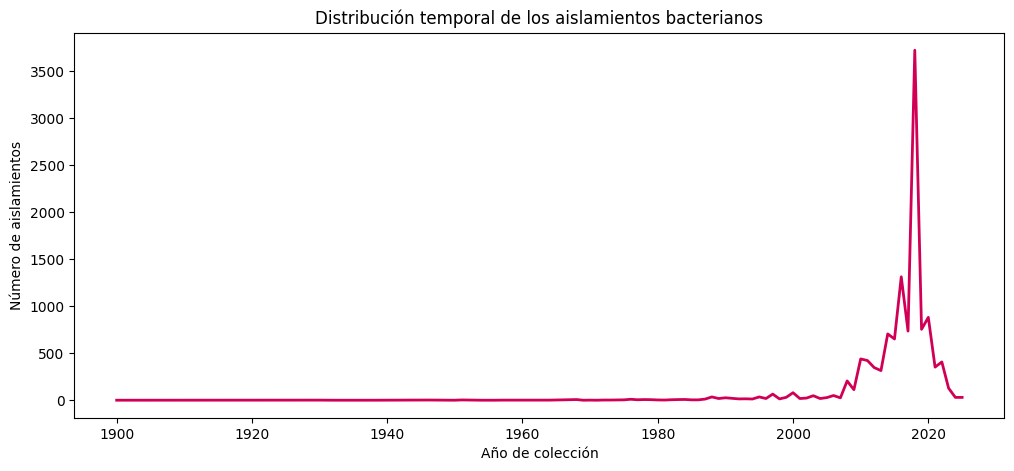

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    aislamientos_por_anio.index,
    aislamientos_por_anio.values,
    color="#D10056",
    linewidth=2
)

plt.xlabel("Año de colección")
plt.ylabel("Número de aislamientos")
plt.title("Distribución temporal de los aislamientos bacterianos")

plt.show()

La distribución temporal mostró una mayor concentración de los aislamientos en los años más recientes. Entre 1900 y aproximadamente la década de 1980, la cantidad de aislamientos fue baja. A partir de las décadas de 1990 y 2000 se observó un aumento progresivo, que fue más marcado durante la década de 2010. La mayor concentración se presentó alrededor de 2018, seguida de una disminución en los años posteriores.

Este patrón muestra que los datos disponibles en BV-BRC no tuvieron una distribución temporal uniforme. Por ello, los cambios observados a través de los años deben interpretarse considerando la disponibilidad y acumulación de datos genómicos, y no necesariamente como un cambio real en la abundancia o distribución de las bacterias asociadas con animales silvestres.

## Distribución taxonómica de los aislamientos

Se examinó la distribución de los aislamientos según el nivel taxonómico de filo (Phylum) para identificar los principales grupos bacterianos representados en el conjunto de datos y conocer su frecuencia relativa.

In [60]:
frecuencia_phylum = (
    wildlife_animales["Phylum"]
    .value_counts()
)

frecuencia_phylum

,count
Phylum,
Bacillota,4461
Pseudomonadota,3907
Bacteroidota,2828
Actinomycetota,848
Campylobacterota,720
Spirochaetota,147
Mycoplasmatota,102
Thermodesulfobacteriota,65
Synergistota,56


In [62]:
# Calcular la proporción de cada filo
porcentaje_phylum = (
    wildlife_animales["Phylum"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

porcentaje_phylum

,proportion
Phylum,
Bacillota,32.90
Pseudomonadota,28.81
Bacteroidota,20.86
Actinomycetota,6.25
Campylobacterota,5.31
Spirochaetota,1.08
Mycoplasmatota,0.75
Thermodesulfobacteriota,0.48
Synergistota,0.41


La composición taxonómica estuvo dominada por cinco filos bacterianos principales. Bacillota presentó la mayor proporción, con 4,461 aislamientos (32.90 %), seguido de Pseudomonadota, con 3,907 (28.81 %), y Bacteroidota, con 2,828 (20.86 %). Actinomycetota y Campylobacterota representaron 6.25 % y 5.31 %, respectivamente. En conjunto, estos cinco filos concentraron aproximadamente el 94.13 % de los datos con información disponible para Phylum.

Los demás filos presentaron proporciones mayormente inferiores al 1.1 %. Esto mostró que la composición bacteriana estuvo concentrada principalmente en unos pocos filos, mientras que una mayor diversidad de filos estuvo representada por cantidades menores de aislamientos.

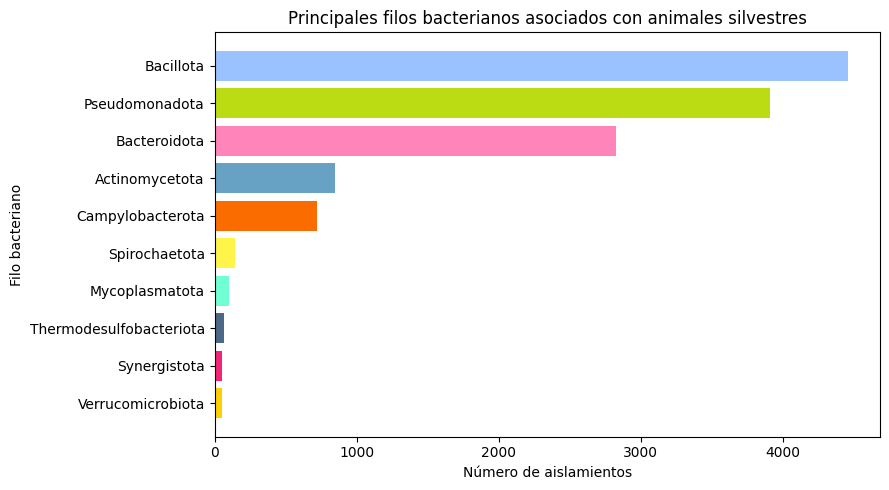

In [67]:
# Definir una paleta de colores pastel para cada filo
colores_phylum = {
    "Bacillota": "#99C2FF",
    "Pseudomonadota": "#BBDC12",
    "Bacteroidota": "#FF84BA",
    "Actinomycetota": "#67A2C5",
    "Campylobacterota": "#FB6C00",
    "Spirochaetota": "#FFF449",
    "Mycoplasmatota": "#70FFD2",
    "Thermodesulfobacteriota": "#4D6787",
    "Synergistota": "#F62477",
    "Verrucomicrobiota": "#FFCF00"
}

# Seleccionar los 10 filos con mayor frecuencia
# y ordenarlos de menor a mayor para la gráfica
top_phylum = frecuencia_phylum.head(10).sort_values()


# Asignar el color correspondiente a cada filo
colores = [
    colores_phylum[phylum]
    for phylum in top_phylum.index
]

import matplotlib.pyplot as plt

# Crear la figura
plt.figure(figsize=(9, 5))

# Generar una barra con un color pastel para cada filo
plt.barh(
    top_phylum.index,
    top_phylum.values,
    color=colores
)

# Agregar etiquetas y título
plt.xlabel("Número de aislamientos")
plt.ylabel("Filo bacteriano")
plt.title("Principales filos bacterianos asociados con animales silvestres")

# Ajustar la distribución de los elementos
plt.tight_layout()

# Mostrar la gráfica
plt.show()

La distribución de los principales filos bacterianos mostró diferencias en su representación. Bacillota fue el filo con mayor frecuencia, seguido de Pseudomonadota y Bacteroidota. En contraste, Thermodesulfobacteriota, Synergistota y Verrucomicrobiota presentaron una representación considerablemente menor. En general, los resultados mostraron que una gran parte de los aislamientos perteneció a un grupo reducido de filos bacterianos.

## Distribución de los principales filos a través del tiempo

Se analizó la distribución temporal de los filos bacterianos con mayor representación en el conjunto de datos. Debido a la presencia de numerosos filos con frecuencias bajas, se seleccionaron los cinco más frecuentes para facilitar la comparación de sus tendencias a través de los años.


In [68]:
# Seleccionar los cinco filos con mayor frecuencia
top_5_phylum = frecuencia_phylum.head(5).index.tolist()

# Mostrar los filos seleccionados
top_5_phylum

['Bacillota',
 'Pseudomonadota',
 'Bacteroidota',
 'Actinomycetota',
 'Campylobacterota']

Los cinco filos seleccionados fueron Bacillota, Pseudomonadota, Bacteroidota, Actinomycetota y Campylobacterota. En conjunto, representaron aproximadamente el 94.13 % de los datos con información disponible para Phylum, por lo que concentraron la mayor parte de la composición taxonómica.

### Selección de los datos temporales

Para el análisis temporal se conservaron únicamente los datos que contaron con año de colección y que pertenecieron a alguno de los cinco filos seleccionados.

In [69]:
# Seleccionar datos con año de colección disponible
# y pertenecientes a los cinco principales filos
temporal_phylum = wildlife_animales[
    wildlife_animales["Collection Year"].notna() &
    wildlife_animales["Phylum"].isin(top_5_phylum)
].copy()

# Mostrar las primeras observaciones seleccionadas
temporal_phylum[
    ["Collection Year", "Phylum"]
].head()

,Collection Year,Phylum
1,2017,Bacteroidota
2,1997,Pseudomonadota
3,1999,Bacteroidota
4,2000,Bacteroidota
5,1989,Bacteroidota


###Frecuencia de los principales filos por año

Se calculó la cantidad de aislamientos pertenecientes a cada uno de los cinco filos seleccionados para cada año de colección. Esto permitió comparar su distribución temporal a partir de las frecuencias absolutas.

In [70]:
# Contar los aislamientos de cada filo para cada año
phylum_por_anio = (
    temporal_phylum
    .groupby(["Collection Year", "Phylum"])
    .size()
    .unstack(fill_value=0)
)

# Mostrar los primeros años
phylum_por_anio.head()

Phylum,Actinomycetota,Bacillota,Bacteroidota,Campylobacterota,Pseudomonadota
Collection Year,,,,,
1900,0,0,1,0,0
1930,2,0,0,0,0
1932,0,0,1,0,0
1938,0,0,0,0,1
1946,0,3,0,0,0


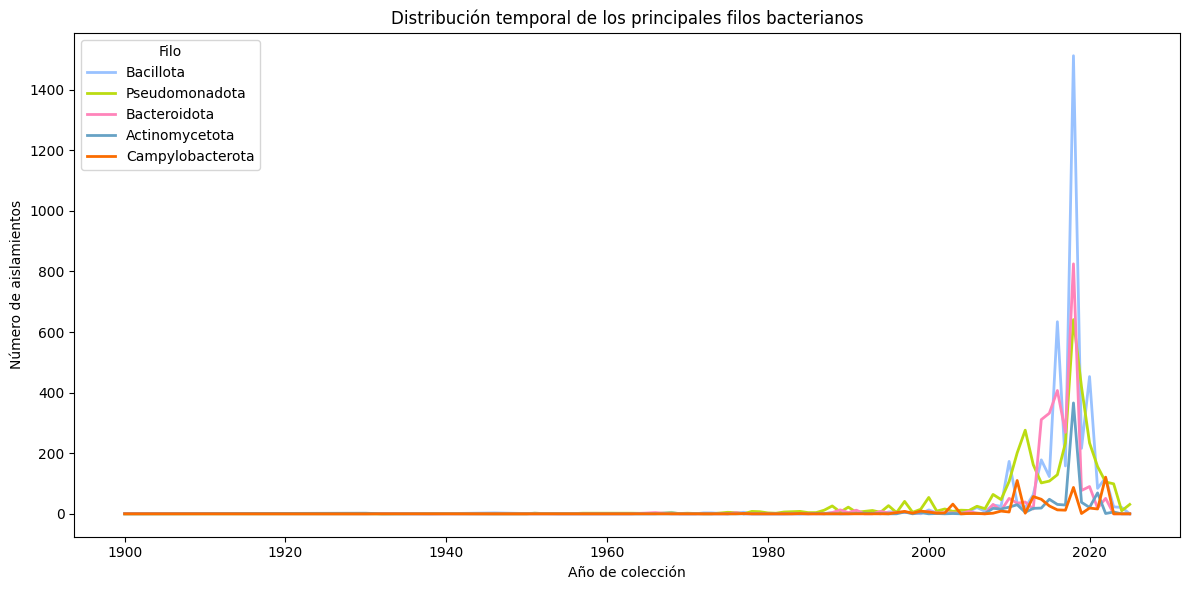

In [ ]:
import matplotlib.pyplot as plt

# Crear la figura
plt.figure(figsize=(12, 6))

# Graficar cada filo a través del tiempo
for phylum in top_5_phylum:
    plt.plot(
        phylum_por_anio.index,
        phylum_por_anio[phylum],
        label=phylum,
        color=colores_phylum[phylum],
        linewidth=2
    )

# Agregar etiquetas y título
plt.xlabel("Año de colección")
plt.ylabel("Número de aislamientos")
plt.title("Distribución temporal de los principales filos bacterianos")

# Mostrar la leyenda
plt.legend(title="Filo")

# Ajustar la distribución de los elementos
plt.tight_layout()

# Mostrar la gráfica
plt.show()

La distribución temporal mostró diferencias en la cantidad de aislamientos disponibles entre los años. Durante las primeras décadas se observó una menor cantidad de datos, mientras que la mayor concentración se presentó en los años más recientes, especialmente entre 2015 y 2022. Bacillota presentó la mayor frecuencia durante los años con mayor cantidad de datos, seguido principalmente por Bacteroidota y Pseudomonadota. Esta distribución mostró un desbalance temporal en los datos, por lo que las diferencias entre los primeros años y los periodos recientes deben interpretarse considerando la cantidad de información disponible para cada año.

#### Proporción anual

Debido a que la cantidad total de aislamientos varió considerablemente entre los años, también calcularemos la proporción que representó cada filo dentro de los cinco filos seleccionados en cada año.

In [71]:
# Calcular el total de los cinco filos para cada año
total_por_anio = phylum_por_anio.sum(axis=1)

# Calcular la proporción de cada filo dentro de cada año
phylum_proporcion_anual = (
    phylum_por_anio
    .div(total_por_anio, axis=0)
    .mul(100)
    .round(2)
)

# Mostrar los primeros años
phylum_proporcion_anual.head()

Phylum,Actinomycetota,Bacillota,Bacteroidota,Campylobacterota,Pseudomonadota
Collection Year,,,,,
1900,0.0,0.0,100.0,0.0,0.0
1930,100.0,0.0,0.0,0.0,0.0
1932,0.0,0.0,100.0,0.0,0.0
1938,0.0,0.0,0.0,0.0,100.0
1946,0.0,100.0,0.0,0.0,0.0


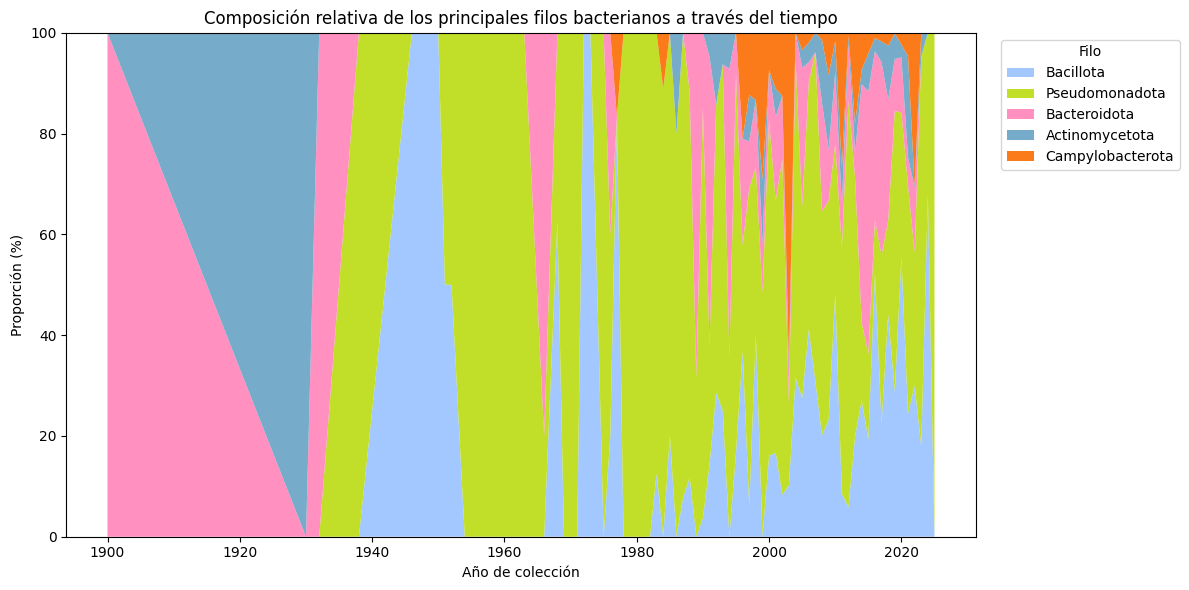

In [73]:
# Crear la figura
plt.figure(figsize=(12, 6))

# Obtener los años y las proporciones de cada filo
anios = phylum_proporcion_anual.index

# Graficar las proporciones acumuladas
plt.stackplot(
    anios,
    *[
        phylum_proporcion_anual[phylum]
        for phylum in top_5_phylum
    ],
    labels=top_5_phylum,
    colors=[
        colores_phylum[phylum]
        for phylum in top_5_phylum
    ],
    alpha=0.9
)

# Configurar el eje Y como porcentaje
plt.ylim(0, 100)

# Agregar etiquetas y título
plt.xlabel("Año de colección")
plt.ylabel("Proporción (%)")
plt.title("Composición relativa de los principales filos bacterianos a través del tiempo")

# Mostrar la leyenda
plt.legend(title="Filo", bbox_to_anchor=(1.02, 1), loc="upper left")

# Ajustar los elementos de la figura
plt.tight_layout()

# Mostrar la gráfica
plt.show()

La composición relativa mostró variaciones en los cinco principales filos a través del tiempo. Sin embargo, en los años con pocos aislamientos, las proporciones fueron más extremas, ya que uno o pocos datos podían representar la mayoría o la totalidad de los aislamientos disponibles. Por esta razón, los primeros años deben interpretarse con precaución. En los años con mayor cantidad de datos, la visualización permitió observar diferencias en la composición relativa de los principales filos bacterianos.

## Relación entre el hospedero y los grupos bacterianos

#### Distribución de los principales filos según el grupo de hospedero

Se comparó la distribución de los cinco principales filos bacterianos entre los diferentes grupos de hospederos. Para ello, se utilizaron las variables Host Group y Phylum.

Como en el análisis temporal, se conservaron los cinco filos con mayor frecuencia para facilitar la comparación y mantener consistencia entre los análisis.

In [74]:
# Seleccionar los datos que cuentan con grupo de hospedero y filo bacteriano
host_phylum = wildlife_animales[
    wildlife_animales["Host Group"].notna() &
    wildlife_animales["Phylum"].isin(top_5_phylum)
].copy()

# Mostrar las primeras observaciones
host_phylum[
    ["Host Group", "Phylum"]
].head()

,Host Group,Phylum
0,Fish,Bacillota
1,Fish,Bacteroidota
2,Fish,Pseudomonadota
3,Fish,Bacteroidota
4,Fish,Bacteroidota


**Frecuencia de los principales filos según el grupo de hospedero**

Se calculó la cantidad de aislamientos pertenecientes a cada filo dentro de cada grupo de hospedero. Esto permitió conocer la distribución absoluta de los principales grupos bacterianos.

In [75]:
# Contar los aislamientos de cada filo dentro de cada grupo de hospedero
phylum_por_host = (
    host_phylum
    .groupby(["Host Group", "Phylum"])
    .size()
    .unstack(fill_value=0)
)

# Mostrar la tabla resultante
phylum_por_host

Phylum,Actinomycetota,Bacillota,Bacteroidota,Campylobacterota,Pseudomonadota
Host Group,,,,,
Avian,6,101,47,293,734
Fish,1,306,1082,0,777
Insect,180,585,26,0,648
Nonhuman Mammal,555,3211,1370,414,1255
Sea Mammal,22,42,52,8,134
Tick,0,0,0,0,1


La distribución mostró diferencias en la cantidad de aislamientos entre los grupos de hospederos. Nonhuman Mammal presentó la mayor cantidad de datos, mientras que Tick presentó una representación mínima.

Por ejemplo, dentro de Nonhuman Mammal, Bacillota presentó 3,211 aislamientos, mientras que en Fish el filo con mayor frecuencia fue Bacteroidota, con 1,082 aislamientos. En Avian, Pseudomonadota presentó la mayor frecuencia, con 734 aislamientos.

**Proporción de los principales filos dentro de cada grupo de hospedero**

Debido a que los grupos de hospederos presentaron cantidades diferentes de aislamientos, se calcularon también las proporciones correspondientes a cada filo dentro de cada grupo.

In [76]:
# Calcular el total de aislamientos de los cinco filos para cada grupo de hospedero
total_por_host = phylum_por_host.sum(axis=1)

# Calcular la proporción de cada filo dentro de cada grupo de hospedero
phylum_proporcion_host = (
    phylum_por_host
    .div(total_por_host, axis=0)
    .mul(100)
    .round(2)
)

# Mostrar las proporciones
phylum_proporcion_host

Phylum,Actinomycetota,Bacillota,Bacteroidota,Campylobacterota,Pseudomonadota
Host Group,,,,,
Avian,0.51,8.55,3.98,24.81,62.15
Fish,0.05,14.13,49.95,0.00,35.87
Insect,12.51,40.65,1.81,0.00,45.03
Nonhuman Mammal,8.16,47.19,20.13,6.08,18.44
Sea Mammal,8.53,16.28,20.16,3.10,51.94
Tick,0.00,0.00,0.00,0.00,100.00


La composición relativa mostró diferencias entre los grupos de hospederos. Bacteroidota presentó una mayor proporción en peces, mientras que Bacillota tuvo una mayor proporción en mamíferos no humanos. Pseudomonadota presentó una proporción elevada en aves, insectos y mamíferos marinos.

###Visualización de la composición bacteriana según el grupo de hospedero

Para facilitar la comparación entre grupos de hospederos y filos bacterianos, se utilizó un mapa de calor (heatmap). En esta visualización, las filas representaron los grupos de hospederos, las columnas representaron los principales filos bacterianos y la intensidad del color indicó la proporción de cada filo.

Debido a que Tick estuvo representado por un solo aislamiento, se excluyó únicamente de esta visualización para evitar que su proporción del 100 % generara una interpretación visual desproporcionada. Esta exclusión correspondió únicamente a la gráfica y no modificó la base de datos ni los análisis anteriores.

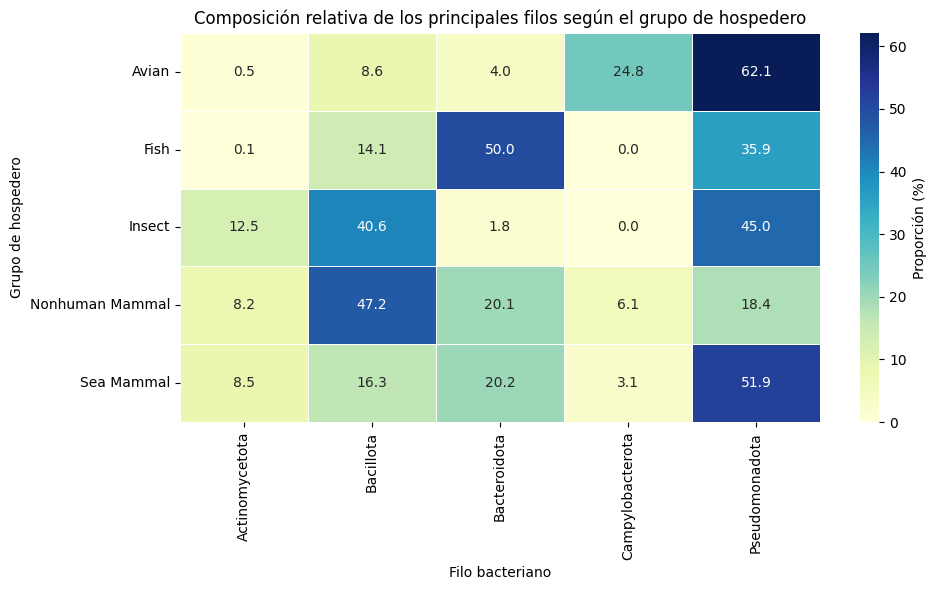

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Excluir Tick únicamente de esta visualización
# debido a que cuenta con un solo aislamiento
heatmap_host = phylum_proporcion_host.drop(index="Tick")

# Crear la figura
plt.figure(figsize=(10, 6))

# Generar el mapa de calor
sns.heatmap(
    heatmap_host,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Proporción (%)"}
)

# Agregar etiquetas y título
plt.xlabel("Filo bacteriano")
plt.ylabel("Grupo de hospedero")
plt.title("Composición relativa de los principales filos según el grupo de hospedero")

# Ajustar la figura
plt.tight_layout()

# Mostrar
plt.show()

El heatmap mostró diferencias en la composición relativa de los principales filos bacterianos entre los grupos de hospederos. Pseudomonadota presentó la mayor proporción en Avian (62.1 %) y Sea Mammal (51.9 %), mientras que Bacteroidota predominó en Fish (50.0 %). En Insect, los filos con mayor representación fueron Pseudomonadota (45.0 %) y Bacillota (40.6 %). En Nonhuman Mammal, Bacillota presentó la mayor proporción (47.2 %).

También se observó una mayor proporción de Campylobacterota en Avian (24.8 %) en comparación con los demás grupos. En conjunto, los resultados mostraron diferencias en la composición relativa de los principales filos entre los grupos de hospederos. Sin embargo, debido a que los grupos tuvieron diferentes cantidades de aislamientos y algunas categorías estuvieron poco representadas, estos patrones se interpretaron como diferencias observadas en los datos analizados y no como evidencia de una relación causal entre el hospedero y la composición bacteriana.

## Distribución geográfica de los aislamientos bacterianos

En esta sección se exploró la distribución geográfica de los aislamientos bacterianos mediante las variables `Isolation Country` y `Geographic Group`. El análisis permitió identificar los países y regiones geográficas con mayor representación dentro del conjunto de datos.

### Distribución por grupo geográfico

Primero se evaluó la cantidad de aislamientos pertenecientes a cada grupo geográfico disponible en la base de datos.

In [79]:
# Contar los aislamientos según el grupo geográfico
frecuencia_geografica = (
    wildlife_animales["Geographic Group"]
    .dropna()
    .value_counts()
)

# Mostrar la frecuencia de cada grupo geográfico
frecuencia_geografica

,count
Geographic Group,
Europe,2805
Asia,2157
North America,1807
Oceania,705
South America,654
Antarctica,213
Africa,74


Se observó que Europa presentó la mayor cantidad de aislamientos, con 2,805, seguida de Asia con 2,157 y Norteamérica con 1,807. En menor proporción se encontraron Oceanía, Sudamérica, Antártida y África, con 705, 654, 213 y 74 aislamientos, respectivamente. En total, se contó con información de grupo geográfico para 8,415 aislamientos.

### Proporción por grupo geográfico

Para facilitar la comparación entre las diferentes regiones, también se calculó la proporción correspondiente a cada grupo geográfico.

In [80]:
# Calcular la proporción de cada grupo geográfico
proporcion_geografica = (
    frecuencia_geografica
    / frecuencia_geografica.sum()
    * 100
).round(2)

# Mostrar las proporciones
proporcion_geografica

,count
Geographic Group,
Europe,33.33
Asia,25.63
North America,21.47
Oceania,8.38
South America,7.77
Antarctica,2.53
Africa,0.88


Al considerar únicamente los aislamientos con información de grupo geográfico, Europa representó el 33.33 % del conjunto, seguida de Asia (25.63 %) y Norteamérica (21.47 %). Oceanía y Sudamérica representaron el 8.38 % y 7.77 %, respectivamente, mientras que Antártida (2.53 %) y África (0.88 %) tuvieron las menores proporciones. Estos resultados mostraron una distribución geográfica desigual dentro del conjunto de datos.

### Distribución por país

Posteriormente, se analizó la distribución de los aislamientos según el país indicado en Isolation Country.

In [82]:
# Contar los aislamientos según el país de aislamiento
frecuencia_pais = (
    wildlife_animales["Isolation Country"]
    .dropna()
    .value_counts()
)

# Mostrar los 15 países con mayor frecuencia
frecuencia_pais.head(15)

,count
Isolation Country,
China,2009
USA,1702
Australia,1113
Antarctica,528
Chile,437
Lithuania,432
Denmark,413
Canada,395
United Kingdom,378


Se observó una distribución desigual entre los países de aislamiento. China presentó la mayor cantidad de aislamientos, con 2,009, seguida de Estados Unidos con 1,702 y Australia con 1,113. También destacaron Antátida, Chile y Lituania, con 528, 437 y 432 aislamientos, respectivamente. Los demás países incluidos entre los 15 con mayor frecuencia presentaron cantidades inferiores. Estos resultados mostraron que una proporción importante de los datos con información geográfica se concentró en un número reducido de países.

#### Proporción de los principales países

In [83]:
# Calcular la proporción de los 15 países con mayor frecuencia
proporcion_pais = (
    frecuencia_pais.head(15)
    / frecuencia_pais.sum()
    * 100
).round(2)

# Mostrar las proporciones
proporcion_pais

,count
Isolation Country,
China,19.86
USA,16.82
Australia,11.00
Antarctica,5.22
Chile,4.32
Lithuania,4.27
Denmark,4.08
Canada,3.90
United Kingdom,3.74


Considerando los datos con país de aislamiento conocido, China representó el 19.86 %, seguida de Estados Unidos (16.82 %) y Australia (11.00 %). Antártica representó el 5.22 %, mientras que Chile y Lituania representaron el 4.32 % y 4.27 %, respectivamente. En los demás países, la proporción fue inferior al 4.1 %. En conjunto, los resultados mostraron una distribución geográfica heterogénea, con una mayor concentración de los datos en algunos países.

### Visualización de la distribución por país

Para facilitar la comparación entre los países con mayor representación, se generó una gráfica de barras horizontal.

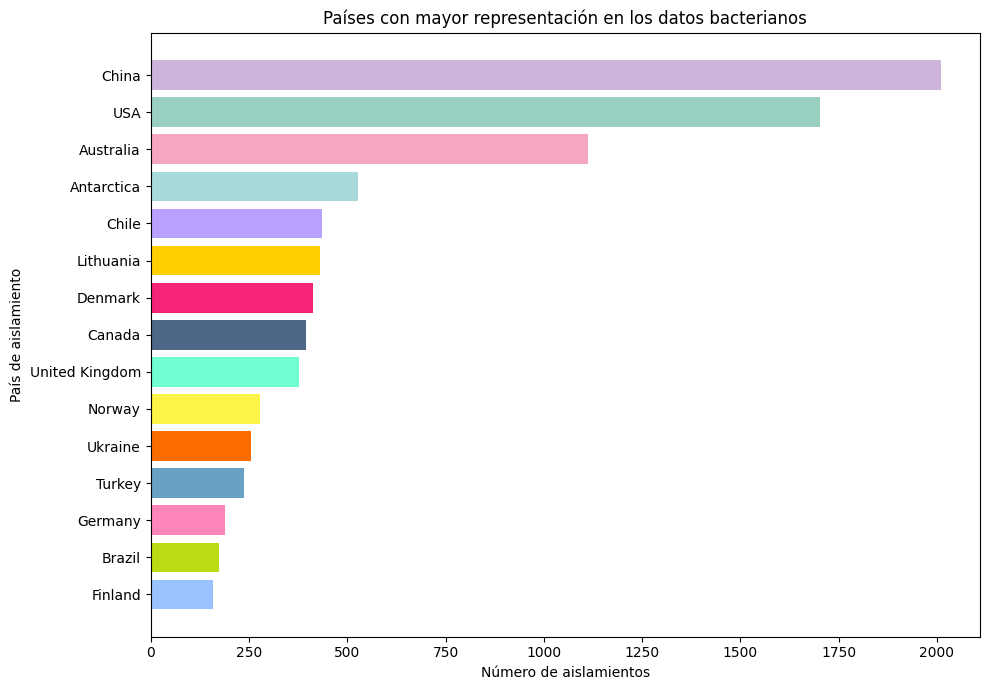

In [85]:
import matplotlib.pyplot as plt

# Seleccionar los 15 países con mayor frecuencia
top_paises = frecuencia_pais.head(15).sort_values()

# Paleta de colores pastel personalizada
colores_paises = [
    "#99C2FF",
    "#BBDC12",
    "#FF84BA",
    "#67A2C5",
    "#FB6C00",
    "#FFF449",
    "#70FFD2",
    "#4D6787",
    "#F62477",
    "#FFCF00",
    "#B8A1FF",
    "#A8DADC",
    "#F7A6C2",
    "#9AD0C2",
    "#CDB4DB"
]

# Crear la figura
plt.figure(figsize=(10, 7))

# Crear la gráfica de barras horizontal
plt.barh(
    top_paises.index,
    top_paises.values,
    color=colores_paises
)

# Agregar etiquetas
plt.xlabel("Número de aislamientos")
plt.ylabel("País de aislamiento")

# Agregar título
plt.title(
    "Países con mayor representación en los datos bacterianos"
)

# Ajustar la figura
plt.tight_layout()

# Mostrar la gráfica
plt.show()

La representación gráfica mostró que China presentó la mayor cantidad de aislamientos, seguida de Estados Unidos y Australia. La diferencia entre estos tres países y el resto fue considerable, especialmente en el caso de China. Los demás países presentaron cantidades menores, lo que mostró una distribución geográfica desigual en los datos disponibles.

In [ ]:
###Distribución geográfica mediante un mapa cloroplético

Para representar espacialmente la distribución de los aislamientos bacterianos, se generó un mapa cloroplético a partir de la variable `Isolation Country`. La intensidad del color representó la cantidad de aislamientos asociados con cada país.

In [86]:
import plotly.express as px

# Crear una tabla con la cantidad de aislamientos por país
datos_mapa = (
    frecuencia_pais
    .rename("Aislamientos")
    .reset_index()
)

# Renombrar la columna con el nombre del país
datos_mapa = datos_mapa.rename(
    columns={"Isolation Country": "Country"}
)

# Estandarizar algunos nombres para facilitar
# su reconocimiento en el mapa
nombres_paises = {
    "USA": "United States",
    "UK": "United Kingdom"
}

datos_mapa["Country"] = datos_mapa["Country"].replace(nombres_paises)

# Mostrar las primeras filas
datos_mapa.head()

,Country,Aislamientos
0,China,2009
1,United States,1702
2,Australia,1113
3,Antarctica,528
4,Chile,437


In [103]:
# Crear el mapa cloroplético
fig = px.choropleth(
    datos_mapa,
    locations="Country",
    locationmode="country names",
    color="Aislamientos",
    hover_name="Country",
    color_continuous_scale=[
   "#FFD6E7",
    "#FF84BA",
    "#D8B4E2",
    "#9ED8C0",
    "#7DCCAD",
      "#24B1B1"
    ],
    labels={
        "Aislamientos": "Número de aislamientos"
    },
    title="Distribución geográfica de los aislamientos bacterianos"
)

# Ajustar el tamaño y la apariencia del mapa
fig.update_layout(
    width=1000,
    height=600
)

# Mostrar el mapa
fig.show()

El mapa cloroplético mostró una distribución geográfica heterogénea de los aislamientos bacterianos. Las mayores concentraciones se observaron principalmente en China, Estados Unidos y Australia, que también presentaron las mayores cantidades de aislamientos en el análisis anterior. En contraste, numerosos países presentaron una menor cantidad de aislamientos. El mapa permitió observar de manera conjunta la distribución geográfica de los datos y complementó la comparación realizada mediante la gráfica de barras.



## Características genómicas

Después de analizar las dimensiones temporal, taxonómica, del hospedero y geográfica, se exploraron las características genómicas de los aislamientos bacterianos. Esta sección permite describir propiedades relacionadas con la estructura, composición y calidad de los genomas disponibles en el conjunto de datos.

Se analizaron cinco variables relacionadas con las características estructurales y de calidad de los genomas bacterianos: `Size`, `GC Content`, `CDS`, `Contigs` y `CheckM Completeness`. Estas variables permiten complementar la caracterización de los aislamientos al incorporar información sobre el tamaño de los genomas, su composición, el número de secuencias codificantes, el grado de fragmentación del ensamblaje y la completitud estimada de los genomas.

### Exploración de las características genómicas



Se seleccionaron las variables genómicas de interés para realizar una descripción general de sus valores y posteriormente evaluar su comportamiento mediante diferentes visualizaciones.

In [104]:
# Seleccionar las características genómicas de interés
variables_genomicas = [
    "Size",
    "GC Content",
    "CDS",
    "Contigs",
    "CheckM Completeness"
]

# Mostrar las primeras observaciones
wildlife_animales[variables_genomicas].head()

,Size,GC Content,CDS,Contigs,CheckM Completeness
0,2171472,38.680000,2120,25,100.0
1,5741890,35.872627,6009,703,100.0
2,4714837,60.505210,4473,26,100.0
3,3405213,31.640928,3327,223,100.0
4,3187672,31.924960,3112,437,99.8


###Estadística descriptiva

Se calcularon estadísticas descriptivas para conocer la distribución general de las características genómicas seleccionadas.

In [105]:
# Obtener estadísticas descriptivas de las variables genómicas
wildlife_animales[variables_genomicas].describe()

,Size,GC Content,CDS,Contigs,CheckM Completeness
count,1.365300e+04,13640.000000,13653.000000,13653.000000,13144.000000
mean,2.880604e+06,44.934199,2862.900095,144.799971,90.450296
std,1.482728e+06,10.600121,1480.781938,199.148703,17.852727
min,3.450000e+02,22.890000,1.000000,1.000000,4.170000
25%,1.838289e+06,35.804934,1860.000000,33.000000,91.490000
50%,2.494021e+06,44.900654,2445.000000,83.000000,98.600000
75%,3.742168e+06,50.814604,3729.000000,170.000000,99.900000
max,1.363213e+07,75.415930,13135.000000,2779.000000,100.000000


El tamaño de los genomas presentó una media de aproximadamente 2.88 millones de pares de bases, con valores entre 345 y 13.63 millones. El contenido de GC tuvo una media de 44.93 %, con valores entre 22.89 % y 75.42 %. El número de secuencias codificantes presentó una media de 2,862.9, mientras que el número de contigs tuvo una media de 144.8. Por su parte, CheckM Completeness presentó una media de 90.45 %, con valores entre 4.17 % y 100 %. En general, los valores mostraron una variación considerable en algunas características genómicas, principalmente en el tamaño del genoma, el número de CDS y el número de contigs.

###Revisión de valores faltantes

Antes de realizar las visualizaciones, se evaluó la disponibilidad de información para cada característica genómica.

In [106]:
# Calcular la cantidad y porcentaje de valores faltantes
faltantes_genomicas = pd.DataFrame({
    "Valores faltantes": wildlife_animales[variables_genomicas].isna().sum(),
    "Porcentaje": (
        wildlife_animales[variables_genomicas].isna().sum()
        / len(wildlife_animales) * 100
    ).round(2)
})

# Mostrar las variables con valores faltantes
faltantes_genomicas[
    faltantes_genomicas["Valores faltantes"] > 0
].sort_values(
    "Porcentaje",
    ascending=False
)

,Valores faltantes,Porcentaje
CheckM Completeness,509,3.73
GC Content,13,0.10


La mayoría de las características genómicas presentó información completa. `GC Content` presentó únicamente 13 valores faltantes, equivalentes al 0.10 % de los datos, mientras que `CheckM Completeness` presentó 509 valores faltantes, correspondientes al 3.73 %. Las variables` Size`, `CDS` y `Contigs` no presentaron valores faltantes. Debido a la baja proporción de datos faltantes, estas variables pudieron utilizarse en los análisis posteriores considerando la disponibilidad específica de información para cada comparación.


### Distribución del tamaño de los genomas

Se examinó la distribución del tamaño de los genomas mediante una gráfica de densidad. Esta visualización permite identificar las principales concentraciones de valores, la dispersión y posibles patrones de asimetría en el tamaño de los genomas analizados.

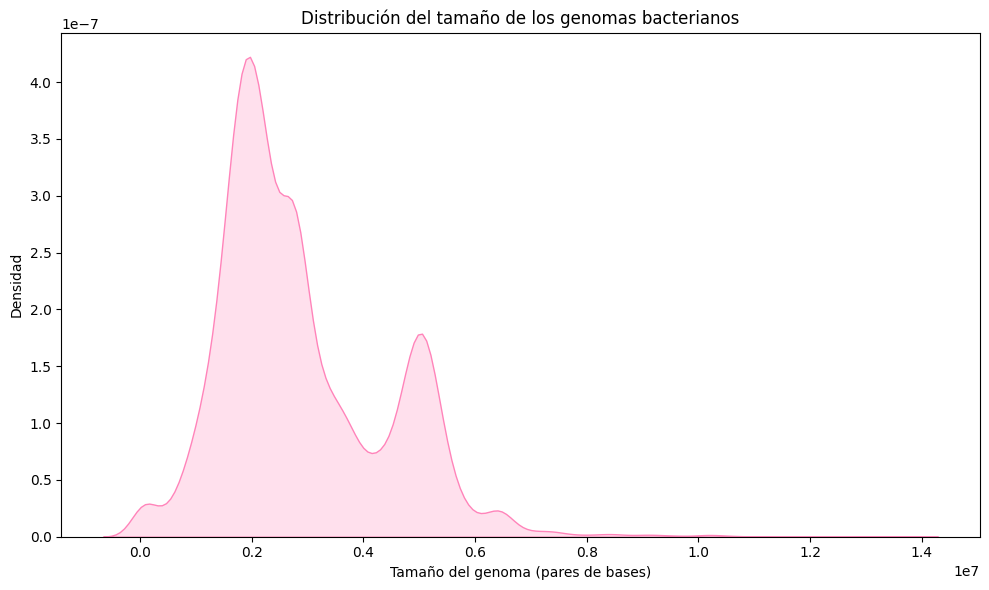

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar únicamente los valores disponibles de tamaño del genoma
size_data = wildlife_animales["Size"].dropna()

# Crear la gráfica de densidad
plt.figure(figsize=(10, 6))

sns.kdeplot(
    size_data,
    fill=True,
    color="#FF84BA"
)

# Agregar etiquetas
plt.xlabel("Tamaño del genoma (pares de bases)")
plt.ylabel("Densidad")
plt.title("Distribución del tamaño de los genomas bacterianos")

# Ajustar la figura
plt.tight_layout()

# Mostrar la gráfica
plt.show()

La distribución del tamaño de los genomas mostró una mayor concentración de valores alrededor de 2–3 millones de pares de bases y un segundo grupo cercano a los 5 millones. También se observó una cola hacia tamaños mayores, con valores superiores a 10 millones de pares de bases. En general, los datos mostraron una distribución asimétrica y variación considerable en el tamaño de los genomas analizados.

### Relación entre tamaño del genoma y número de CDS

Se exploró la relación entre el tamaño de los genomas bacterianos y el número de secuencias codificantes (CDS) mediante un diagrama de dispersión. Esta visualización permitió observar la relación entre ambas características e identificar posibles tendencias y valores atípicos.

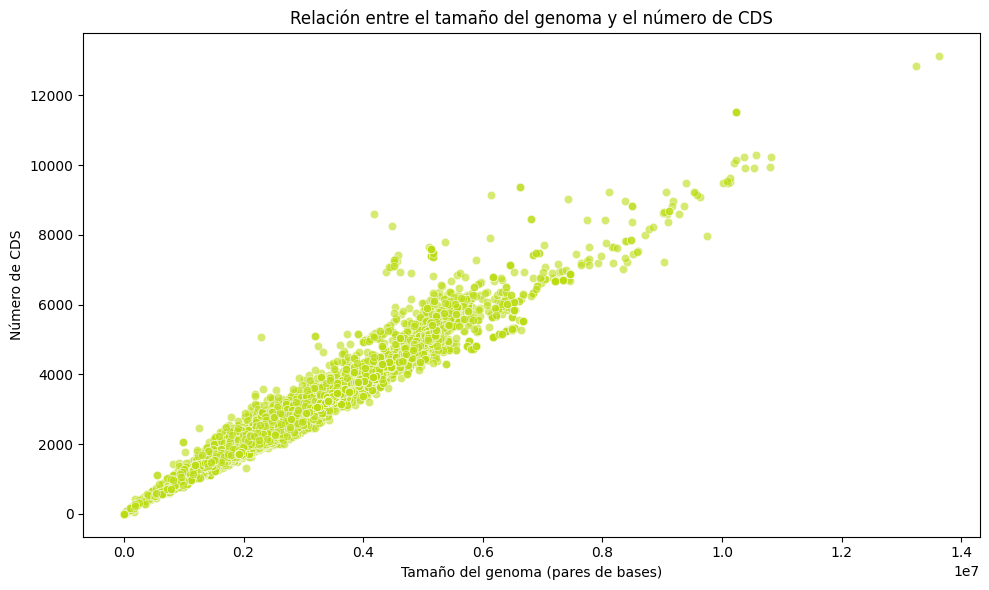

In [112]:
# Seleccionar los datos disponibles para ambas variables
datos_size_cds = wildlife_animales[
    ["Size", "CDS"]
].dropna()

# Crear el scatterplot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=datos_size_cds,
    x="Size",
    y="CDS",
    color="#BBDC12",
    alpha=0.6
)

# Agregar etiquetas
plt.xlabel("Tamaño del genoma (pares de bases)")
plt.ylabel("Número de CDS")
plt.title("Relación entre el tamaño del genoma y el número de CDS")

# Ajustar la figura
plt.tight_layout()

# Mostrar la gráfica
plt.show()

In [ ]:
# Calcular la correlación entre el tamaño del genoma y el número de CDS
correlacion_size_cds = datos_size_cds["Size"].corr(
    datos_size_cds["CDS"]
)

print(f"Correlación entre Size y CDS: {correlacion_size_cds:.3f}")

Correlación entre Size y CDS: 0.979


Se observó una relación positiva entre el tamaño del genoma y el número de secuencias codificantes (CDS). En general, los genomas de mayor tamaño presentaron un mayor número de CDS, mostrando una tendencia ascendente entre ambas variables. La mayor concentración de datos se encontró en genomas de aproximadamente 1 a 6 millones de pares de bases y entre 1,000 y 6,000 CDS. También se identificaron algunas observaciones alejadas de la tendencia general, principalmente en los genomas de mayor tamaño.

El coeficiente de correlación fue de 0.979, lo que indica una relación positiva muy fuerte entre ambas variables. Este resultado coincide con el patrón observado en el diagrama de dispersión y confirma la asociación marcada entre el tamaño del genoma y el número de CDS en el conjunto analizado.

### Tamaño del genoma según grupo de hospedero



Después de explorar la relación entre dos características genómicas, se evaluó si el tamaño de los genomas presenta diferencias entre los grupos de hospederos. Esta comparación permite integrar la dimensión genómica con la información biológica del hospedero y determinar si existen patrones diferenciados en la distribución del tamaño genómico.

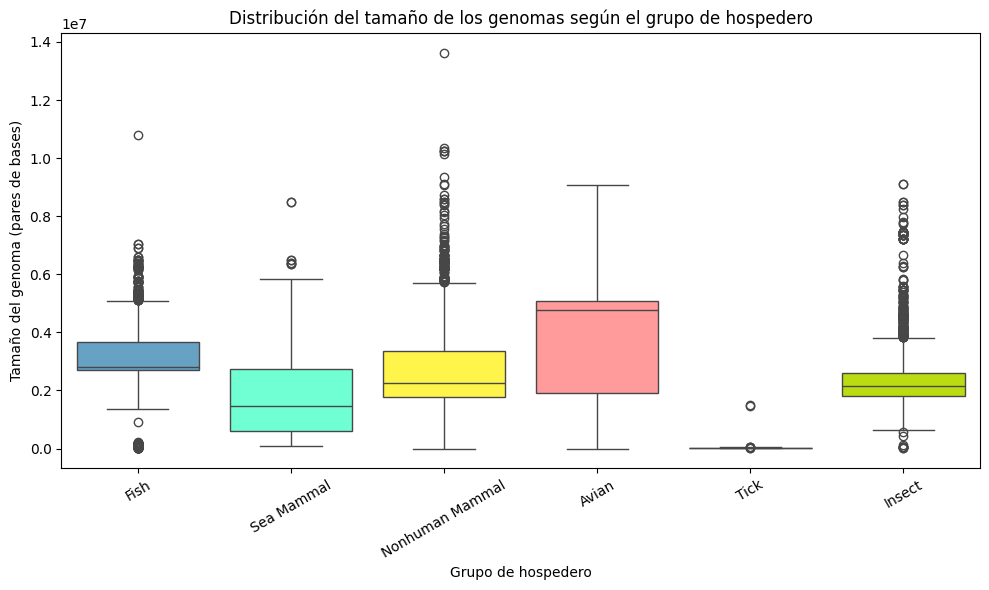

In [119]:
# Seleccionar los datos disponibles para tamaño del genoma y grupo de hospedero
datos_size_host = wildlife_animales[
    ["Host Group", "Size"]
].dropna()

# Definir colores para cada grupo de hospedero
colores_host = {
    "Avian": "#FF9B9B",
    "Fish": "#67A2C5",
    "Insect": "#BBDC12",
    "Nonhuman Mammal": "#FFF449",
    "Sea Mammal": "#70FFD2",
    "Tick": "#FB6C00"
}

# Crear el boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=datos_size_host,
    x="Host Group",
    y="Size",
    hue="Host Group",
    palette=colores_host,
    saturation=1,
    legend=False
)

# Agregar etiquetas
plt.xlabel("Grupo de hospedero")
plt.ylabel("Tamaño del genoma (pares de bases)")
plt.title(
    "Distribución del tamaño de los genomas según el grupo de hospedero"
)

# Rotar las etiquetas
plt.xticks(rotation=30)

# Ajustar la figura
plt.tight_layout()

# Mostrar la gráfica
plt.show()

La distribución del tamaño de los genomas mostró diferencias entre los grupos de hospederos. Las aves presentaron la mediana más alta, mientras que los peces, los mamíferos no humanos y los insectos tuvieron valores centrales menores, aunque con una dispersión considerable. Los mamíferos marinos mostraron una mediana cercana a 1.5 millones de pares de bases, mientras que las garrapatas presentaron los tamaños genómicos más bajos y una distribución más concentrada. También se observaron valores extremos en varios grupos, principalmente en peces, mamíferos no humanos e insectos.

###Contenido de GC según grupo de hospedero

Como siguiente paso, se analizó el contenido de GC según el grupo de hospedero. Esta característica permite comparar la composición de los genomas entre los diferentes grupos y observar posibles diferencias en sus valores de GC.

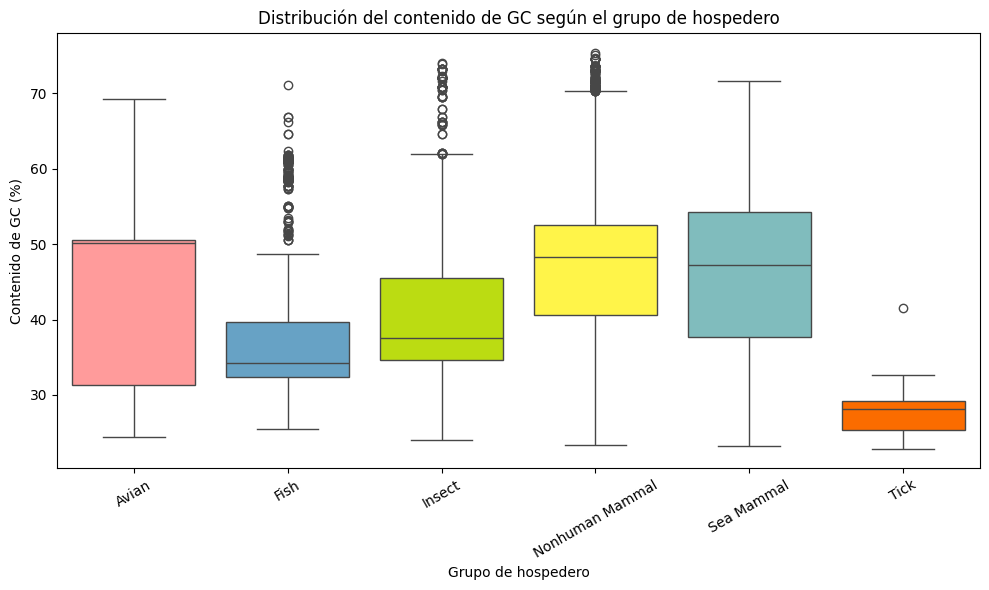

In [121]:
# Seleccionar los datos disponibles para contenido de GC
# y grupo de hospedero
datos_gc_host = wildlife_animales[
    ["Host Group", "GC Content"]
].dropna()

# Definir el orden de los grupos de hospedero
orden_host = [
    "Avian",
    "Fish",
    "Insect",
    "Nonhuman Mammal",
    "Sea Mammal",
    "Tick"
]

# Crear el boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=datos_gc_host,
    x="Host Group",
    y="GC Content",
    hue="Host Group",
    order=orden_host,
    palette=colores_host,
    saturation=1,
    legend=False
)

# Agregar etiquetas
plt.xlabel("Grupo de hospedero")
plt.ylabel("Contenido de GC (%)")
plt.title(
    "Distribución del contenido de GC según el grupo de hospedero"
)

# Rotar las etiquetas
plt.xticks(rotation=30)

# Ajustar la figura
plt.tight_layout()

# Mostrar la gráfica
plt.show()

El contenido de GC mostró diferencias entre los grupos de hospederos. Los mamíferos no humanos presentaron una de las medianas más altas, cercana al 48 %, mientras que los mamíferos marinos tuvieron una mediana alrededor del 47 %. Las aves mostraron una distribución amplia, con valores centrales cercanos al 50 %, mientras que los insectos tuvieron una mediana aproximada de 37 %. En los peces, la mediana fue cercana al 34 %, aunque se observaron valores extremos por encima del 50 %. Las garrapatas presentaron los valores centrales más bajos, alrededor del 28 %, con una distribución más concentrada. En general, los resultados mostraron diferencias en el contenido de GC entre los grupos de hospederos, con una mayor variación en algunos grupos.

##Modelado predictivo


---

A partir de los patrones identificados durante el análisis exploratorio, se desarrolló un modelo de clasificación para evaluar si las características genómicas de los aislamientos bacterianos permitieron predecir el grupo de hospedero al que estaban asociados.

La variable objetivo fue `Host Group`, mientras que las características genómicas consideradas inicialmente como variables predictoras fueron `Size`, `GC Content` y `CDS`. Estas variables se seleccionaron porque habían sido exploradas previamente en el análisis descriptivo y representan diferentes características de los genomas.

### Distribución de la variable objetivo

Antes de entrenar el modelo, se examinó la distribución de la variable `Host Group` con el propósito de identificar posibles desequilibrios entre las categorías.

In [123]:
# Contar la cantidad de observaciones por grupo de hospedero
host_counts = wildlife_animales["Host Group"].value_counts()

# Mostrar la distribución
host_counts

,count
Host Group,
Nonhuman Mammal,7326
Fish,2169
Insect,1452
Avian,1200
Sea Mammal,390
Tick,38


In [124]:
# Calcular la proporción de cada grupo de hospedero
host_proportion = (
    wildlife_animales["Host Group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

host_proportion

,proportion
Host Group,
Nonhuman Mammal,58.26
Fish,17.25
Insect,11.55
Avian,9.54
Sea Mammal,3.10
Tick,0.30


La variable `Host Group` presentó una distribución desigual entre las categorías disponibles. `Nonhuman Mammal` fue el grupo más representado, con 7,326 observaciones (58.26 %), seguido de `Fish` con 2,169 (17.25 %), `Insect` con 1,452 (11.55 %), `Avian` con 1,200 (9.54 %) y `Sea Mamma`l con 390 (3.10 %). `Tick` presentó únicamente 38 observaciones (0.30 %).

Esta distribución evidenció un marcado desbalance entre las categorías, particularmente por la baja representación de Tick. Debido a ello, se consideró necesario excluir esta categoría del modelado para evitar que un número reducido de observaciones dificultara la evaluación del desempeño del clasificador.

### Selección de las categorías para el modelo
Se seleccionaron las cinco categorías con mayor representación: `Nonhuman Mammal`, `Fish`, `Insect`, `Avian` y `Sea Mammal`.

In [125]:
# Definir las categorías seleccionadas para el modelo
categorias_modelo = [
    "Nonhuman Mammal",
    "Fish",
    "Insect",
    "Avian",
    "Sea Mammal"
]

# Filtrar únicamente las categorías seleccionadas
datos_modelo = wildlife_animales[
    wildlife_animales["Host Group"].isin(categorias_modelo)
].copy()

# Comprobar el número de observaciones por categoría
datos_modelo["Host Group"].value_counts()

,count
Host Group,
Nonhuman Mammal,7326
Fish,2169
Insect,1452
Avian,1200
Sea Mammal,390


In [126]:
# Comprobar el número total de observaciones seleccionadas
print("Observaciones para el modelo:", len(datos_modelo))

Observaciones para el modelo: 12537


La variable `Host Group` presentó una distribución desigual entre las categorías disponibles. Nonhuman Mammal fue el grupo más representado, con 7,326 observaciones (58.26 %), seguido de Fish con 2,169 (17.25 %), Insect con 1,452 (11.55 %), Avian con 1,200 (9.54 %) y Sea Mammal con 390 (3.10 %). Tick presentó únicamente 38 observaciones (0.30 %).

Esta distribución evidenció un marcado desbalance entre las categorías, particularmente por la baja representación de Tick. Debido a ello, se consideró necesario excluir esta categoría del modelado para evitar que un número reducido de observaciones dificultara la evaluación del desempeño del clasificador.

### Selección de variables predictoras

Para evaluar si las características genómicas permiten diferenciar los grupos de hospederos, se seleccionaron `Size`, `GC  Content` y `CDS` como variables predictoras.

In [127]:
# Definir las variables predictoras
variables_predictoras = [
    "Size",
    "GC Content",
    "CDS"
]

# Definir la variable objetivo
variable_objetivo = "Host Group"

# Crear X e y
X = datos_modelo[variables_predictoras].copy()
y = datos_modelo[variable_objetivo].copy()

# Comprobar las dimensiones
print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (12537, 3)
Variable objetivo: (12537,)


In [128]:
# Revisar valores faltantes en las variables del modelo
print("Valores faltantes en X:")
print(X.isna().sum())

print("\nValores faltantes en y:")
print(y.isna().sum())

Valores faltantes en X:
Size           0
GC Content    13
CDS            0
dtype: int64

Valores faltantes en y:
0


Se identificaron 13 valores faltantes en `GC Content`, mientras que `Size`, `CDS` y `Host Group` no presentaron valores faltantes.

### Preparación de los datos para el modelo

Debido a que únicamente 13 observaciones presentaron información faltante en `GC Content`, estas fueron excluidas exclusivamente del conjunto utilizado para el modelado.

In [132]:
# Eliminar únicamente las observaciones con valores faltantes
# en las variables predictoras
datos_modelo_limpios = datos_modelo[
    variables_predictoras + [variable_objetivo]
].dropna()

# Crear nuevamente X e y
X = datos_modelo_limpios[variables_predictoras]
y = datos_modelo_limpios[variable_objetivo]

# Comprobar los valores faltantes
print("Valores faltantes en X:")
print(X.isna().sum())

print("\nValores faltantes en y:")
print(y.isna().sum())

print("\nObservaciones para el modelo:", len(X))

Valores faltantes en X:
Size          0
GC Content    0
CDS           0
dtype: int64

Valores faltantes en y:
0

Observaciones para el modelo: 12524


### División de los datos

In [133]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Crear el objeto para estandarizar las variables
scaler = StandardScaler()

# Ajustar la estandarización únicamente con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar la misma transformación a los datos de prueba
X_test_scaled = scaler.transform(X_test)

# Comprobar las dimensiones
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (10019, 3)
Datos de prueba: (2505, 3)


El conjunto de entrenamiento estuvo compuesto por 10,019 observaciones, mientras que el conjunto de prueba estuvo compuesto por 2,505 observaciones.
Las variables predictoras se estandarizaron debido a que se encontraban en escalas diferentes. Este procedimiento permitió evitar que las diferencias en la magnitud de las variables influyeran directamente en el ajuste de la regresión logística.

###Entrenamiento del modelo de regresión logística

Se utilizó una regresión logística multiclase para evaluar la capacidad de las características genómicas para clasificar los aislamientos de acuerdo con su grupo de hospedero.

In [134]:
from sklearn.linear_model import LogisticRegression

# Crear el modelo de regresión logística
modelo_logistico = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entrenar el modelo con los datos de entrenamiento
modelo_logistico.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

### Validación cruzada

Para evaluar la estabilidad del modelo y reducir la dependencia de una única partición de los datos, se aplicó una validación cruzada estratificada de cinco particiones.

In [135]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Crear la validación cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluar el modelo mediante validación cruzada
scores = cross_val_score(
    modelo_logistico,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Mostrar el desempeño de cada partición
print("Accuracy de cada partición:")
print(scores)

# Calcular el promedio y la desviación estándar
print(f"\nAccuracy promedio: {scores.mean():.3f}")
print(f"Desviación estándar: {scores.std():.3f}")

Accuracy de cada partición:
[0.64121756 0.6252495  0.62824351 0.63772455 0.63754368]

Accuracy promedio: 0.634
Desviación estándar: 0.006


Los valores de `accuracy` obtenidos en las cinco particiones fueron 0.641, 0.625, 0.628, 0.638 y 0.638, respectivamente. El modelo presentó un accuracy promedio de 0.634, con una desviación estándar de 0.006.

### Evaluación del modelo
Se generaron predicciones sobre el conjunto de prueba y se calcularon métricas de desempeño para cada categoría.

In [136]:
from sklearn.metrics import classification_report

# Generar predicciones sobre el conjunto de prueba
y_pred = modelo_logistico.predict(X_test_scaled)

# Evaluar el desempeño del modelo por categoría
print(classification_report(
    y_test,
    y_pred,
    digits=3
))

                 precision    recall  f1-score   support

          Avian      0.136     0.013     0.023       240
           Fish      0.630     0.541     0.582       434
         Insect      0.000     0.000     0.000       290
Nonhuman Mammal      0.646     0.930     0.763      1465
     Sea Mammal      0.000     0.000     0.000        76

       accuracy                          0.639      2505
      macro avg      0.282     0.297     0.274      2505
   weighted avg      0.500     0.639     0.549      2505



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



El modelo presentó su mejor resultado para Nonhuman Mammal, con un recall de 0.930 y un F1-score de 0.763. Para Fish, se obtuvo un F1-score de 0.582, lo que indicó una capacidad de clasificación moderada. En contraste, el desempeño para Avian fue muy bajo, con un F1-score de 0.023, mientras que Insect y Sea Mammal presentaron valores de F1-score de 0.000. El F1-score macro fue de 0.274, considerablemente menor que el accuracy general de 0.639. Esta diferencia mostró que el modelo no tuvo un desempeño equilibrado entre las categorías y que el accuracy estuvo influenciado principalmente por Nonhuman Mammal, que fue la categoría más representada.

### Matriz de confusión

Para visualizar los aciertos y errores de clasificación entre las diferentes categorías, se construyó una matriz de confusión.

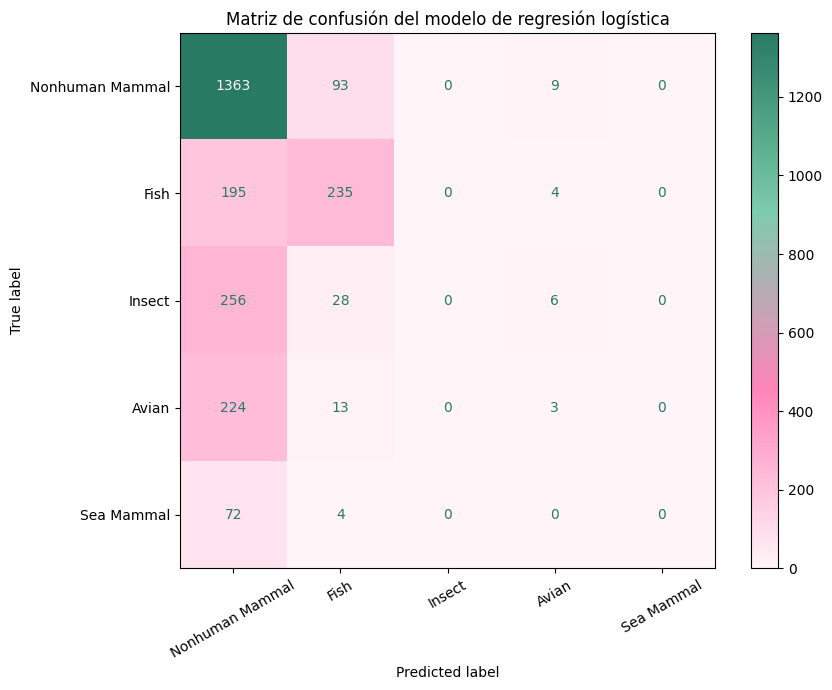

In [141]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import LinearSegmentedColormap


# Calcular la matriz de confusión
matriz_confusion = confusion_matrix(
    y_test,
    y_pred,
    labels=categorias_modelo
)

# Crear una paleta personalizada
cmap_personalizado = LinearSegmentedColormap.from_list(
    "rosa_verde",
    ["#FFF5F8", "#FF84BA", "#7DCCAD", "#287A61"]
)


# Crear la visualización
fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=categorias_modelo
)

disp.plot(
    ax=ax,
    cmap=cmap_personalizado,
    values_format="d",
    colorbar=True
)

# Agregar título
ax.set_title("Matriz de confusión del modelo de regresión logística")

# Rotar etiquetas
plt.xticks(rotation=30)

# Ajustar la figura
plt.tight_layout()

# Mostrar
plt.show()

La matriz de confusión mostró que el modelo clasificó correctamente 1,363 de las 1,465 observaciones de Nonhuman Mammal, aunque 93 fueron clasificadas como Fish y 9 como Avian. Para Fish, 235 de las 434 observaciones fueron clasificadas correctamente, mientras que 195 fueron asignadas a Nonhuman Mammal. En contraste, el modelo presentó mayores dificultades para distinguir Insect, Avian y Sea Mammal. De las 290 observaciones de Insect, 256 fueron clasificadas como Nonhuman Mammal; de las 240 de Avian, 224 fueron asignadas a esta misma categoría; y las 76 observaciones de Sea Mammal fueron clasificadas principalmente como Nonhuman Mammal. En conjunto, la matriz mostró una marcada tendencia del modelo a asignar las observaciones a la categoría más representada.

### Importancia de las variables predictoras

Después de evaluar el desempeño del modelo, se examinó la contribución relativa de las variables genómicas utilizadas como predictores. Para ello, se calcularon los valores absolutos de los coeficientes del modelo de regresión logística y se obtuvo su promedio entre las categorías de Host Group.

In [143]:
import numpy as np

# Obtener los coeficientes del modelo
coeficientes = modelo_logistico.coef_

# Calcular la importancia promedio de cada variable
importancia = np.mean(
    np.abs(coeficientes),
    axis=0
)

# Crear una tabla con las variables y su importancia
importancia_df = pd.DataFrame({
    "Variable": variables_predictoras,
    "Importancia": importancia
})

# Ordenar de mayor a menor importancia
importancia_df = importancia_df.sort_values(
    "Importancia",
    ascending=True
)

# Mostrar los resultados
importancia_df

,Variable,Importancia
2,CDS,0.494004
0,Size,0.526066
1,GC Content,0.618910


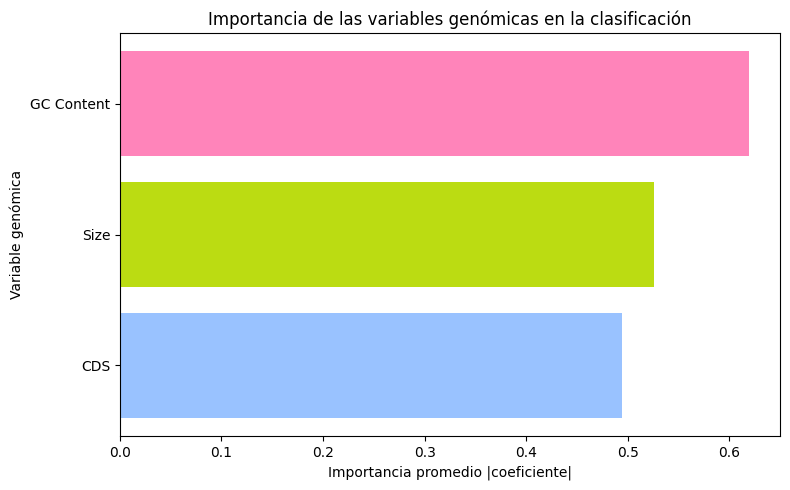

In [147]:
# Colores para cada variable
colores_variables = [
    "#99C2FF",  # Size
    "#BBDC12",  # GC Content
    "#FF84BA"   # CDS
]

plt.figure(figsize=(8, 5))

plt.barh(
    importancia_df["Variable"],
    importancia_df["Importancia"],
    color=colores_variables
)

plt.xlabel("Importancia promedio |coeficiente|")
plt.ylabel("Variable genómica")
plt.title(
    "Importancia de las variables genómicas en la clasificación"
)

plt.tight_layout()
plt.show()

`GC Content` presentó la mayor importancia promedio dentro del modelo, con un valor de 0.619, seguido de Size con 0.526 y `CDS` con 0.494. Esto indicó que, dentro de la regresión logística, el contenido de `GC` tuvo la mayor contribución relativa para diferenciar las categorías de `Host Group`, seguido del tamaño del genoma y el número de `CDS`. Estos valores representan la magnitud de los coeficientes del modelo y no implican una relación causal entre las características genómicas y el grupo de hospedero.

###Conclusión del modelado predictivo

En conjunto, la regresión logística mostró una capacidad predictiva limitada y desigual para clasificar el grupo de hospedero a partir de `Size`, `GC Content` y `CDS`. Aunque el modelo alcanzó un accuracy promedio de 0.634 durante la validación cruzada y de 0.639 en el conjunto de prueba, el F1-score macro de 0.274 y la matriz de confusión mostraron un mejor desempeño para Nonhuman Mammal y Fish que para las demás categorías. Por lo tanto, las características genómicas analizadas no fueron suficientes por sí solas para predecir de manera equilibrada el grupo de hospedero.

## Conclusiones

---
El análisis permitió identificar patrones temporales, taxonómicos y geográficos en los aislamientos bacterianos asociados a animales silvestres. Asimismo, se evaluó la relación entre algunas características genómicas y el grupo de hospedero mediante un modelo de clasificación. Aunque las variables analizadas mostraron diferencias entre las categorías y contribuyeron al proceso de clasificación, el modelo presentó un desempeño desigual y no permitió predecir de manera equilibrada todos los grupos de hospederos.
